In [2]:
pip install --upgrade numpy pandas


  Obtaining dependency information for pandas from https://files.pythonhosted.org/packages/c8/7b/bdcb1ed8fccb63d04bdb7635161d0ec26596d92c9d7a6cce964e7876b6c1/pandas-2.3.1-cp311-cp311-win_amd64.whl.metadata
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.1/11.3 MB 1.1 MB/s eta 0:00:11
   ---------------------------------------- 0.1/11.3 MB 1.1 MB/s eta 0:00:11
    --------------------------------------- 0.2/11.3 MB 1.2 MB/s eta 0:00:10
    --------------------------------------- 0.2/11.3 MB 1.1 MB/s eta 0:00:10
    --------------------------------------- 0.2/11.3 MB 1.1 MB/s eta 0:00:11
   - -------------------------------------- 0.3/11.3 MB 1.2 MB/s eta 0:00:09
   - -------------------------------------- 0.3/11.3 MB 1.1 MB/s eta 0:00:10
   - -------------------------------------- 0.4/11.3 MB 1.2 MB/s eta 0:00:10
   - ---------------------------------

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import randint

In [10]:
# ---------------------
# Data Loading
# ---------------------
def load_data(file_path, target_column):
    df = pd.read_csv(file_path)

    # Drop rows where target is NaN
    df = df.dropna(subset=[target_column])

    X = df.drop(columns=[target_column])
    y = df[target_column]

    return train_test_split(X, y, test_size=0.2, random_state=42)
# ---------------------
# Preprocessing
# ---------------------
def build_preprocessor(X):
    numeric_features = X.select_dtypes(include=[np.number]).columns
    categorical_features = X.select_dtypes(exclude=[np.number]).columns

    # Handle NaN + scale numerics
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    # Handle NaN + encode categoricals
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    return ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features)
        ]
    )

# ---------------------
# Hyperparameter Search
# ---------------------
def get_param_distributions():
    return {
        "model__n_estimators": randint(100, 500),
        "model__max_depth": randint(3, 20),
        "model__min_samples_split": randint(2, 20),
        "model__min_samples_leaf": randint(1, 20),
        "model__max_features": ["sqrt", "log2", None]   # 'auto' removed (deprecated)
    }

def tune_model(X_train, y_train):
    preprocessor = build_preprocessor(X_train)

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(random_state=42))
    ])

    param_dist = get_param_distributions()

    random_search = RandomizedSearchCV(
        pipeline,
        param_distributions=param_dist,
        n_iter=30,
        cv=3,
        scoring="neg_mean_squared_error",
        verbose=2,
        n_jobs=-1,
        random_state=42
    )

    random_search.fit(X_train, y_train)
    return random_search

# ---------------------
# Evaluation
# ---------------------
def evaluate_model(model, X_test, y_test):
    from sklearn.metrics import mean_squared_error, r2_score
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"RMSE: {rmse:.2f}")
    print(f"R²: {r2:.2f}")

In [11]:
file_path = r"C:\Users\dhruv\OneDrive\Desktop\ml\listings.csv"   
target_column = "price"      
    
X_train, X_test, y_train, y_test = load_data(file_path, target_column)
tuned_model = tune_model(X_train, y_train)
evaluate_model(tuned_model, X_test, y_test)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
RMSE: 1307.31
R²: 0.86


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ---------------------------
# Function: Load & preprocess data
# ---------------------------
def load_data(file_path, target_column):
    data = pd.read_csv(file_path)

    # Drop missing values
    data = data.dropna()

    # Select numeric features
    X = data.select_dtypes(include=[np.number]).drop(columns=[target_column], errors="ignore")
    y = data[target_column]

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Scale features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    return X_train, X_test, y_train, y_test

# ---------------------------
# Function: Get Models (A2)
# ---------------------------
def get_models():
    models = {
        "Linear Regression": LinearRegression(),
        "Ridge Regression": Ridge(),
        "Lasso Regression": Lasso(),
        "Decision Tree": DecisionTreeRegressor(random_state=42),
        "Random Forest": RandomForestRegressor(random_state=42),
        "Gradient Boosting": GradientBoostingRegressor(random_state=42),
        "Support Vector Regressor": SVR()
    }
    return models

# ---------------------------
# Function: Evaluate a single model (A4)
# ---------------------------
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}, y_pred

# ---------------------------
# Function: Compare all models (A4)
# ---------------------------
def compare_models(models, X_test, y_test):
    results = {}
    preds = {}

    for name, model in models.items():
        metrics, y_pred = evaluate_model(model, X_test, y_test)
        results[name] = metrics
        preds[name] = y_pred

    results_df = pd.DataFrame(results).T
    return results_df, preds

# ---------------------------
# Function: Visualization (A4)
# ---------------------------
def plot_results(y_test, preds, results_df):
    # Best model based on R²
    best_model = results_df["R2"].idxmax()
    y_pred_best = preds[best_model]

    # 1. Predicted vs Actual
    plt.figure(figsize=(6, 6))
    plt.scatter(y_test, y_pred_best, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
    plt.xlabel("Actual Prices")
    plt.ylabel("Predicted Prices")
    plt.title(f"Predicted vs Actual ({best_model})")
    plt.show()

    # 2. Residuals plot
    residuals = y_test - y_pred_best
    plt.figure(figsize=(6, 4))
    plt.scatter(y_pred_best, residuals, alpha=0.5)
    plt.axhline(0, color="r", linestyle="--")
    plt.xlabel("Predicted Prices")
    plt.ylabel("Residuals")
    plt.title(f"Residual Plot ({best_model})")
    plt.show()

    # 3. Bar chart comparison
    results_df[["MAE", "RMSE", "R2"]].plot(kind="bar", figsize=(10, 6))
    plt.title("Model Performance Comparison")
    plt.ylabel("Score")
    plt.xticks(rotation=45)
    plt.show()

Model Performance:
                                  MAE           MSE         RMSE        R2
Linear Regression         503.059975  6.762787e+06  2600.535972 -0.030134
Ridge Regression          502.952065  6.762548e+06  2600.489920 -0.030097
Lasso Regression          502.005827  6.762377e+06  2600.457063 -0.030071
Decision Tree             205.130092  3.316019e+06  1820.993924  0.494891
Random Forest             257.974481  4.782645e+06  2186.925812  0.271489
Gradient Boosting         221.988447  1.135101e+06  1065.411361  0.827097
Support Vector Regressor  277.565165  6.590131e+06  2567.125008 -0.003834


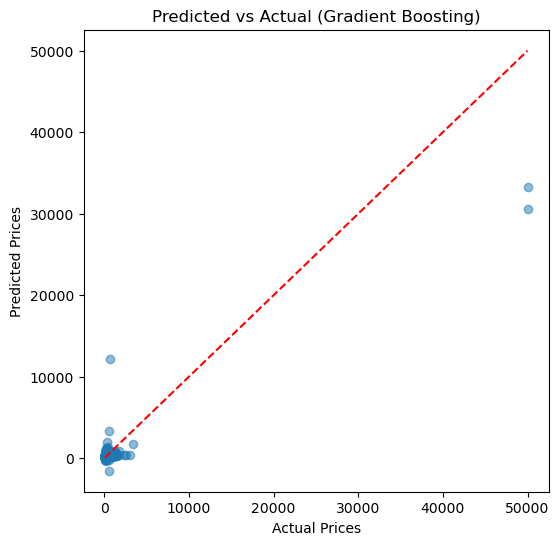

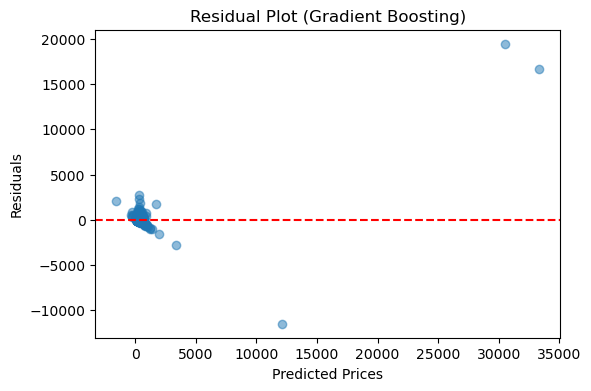

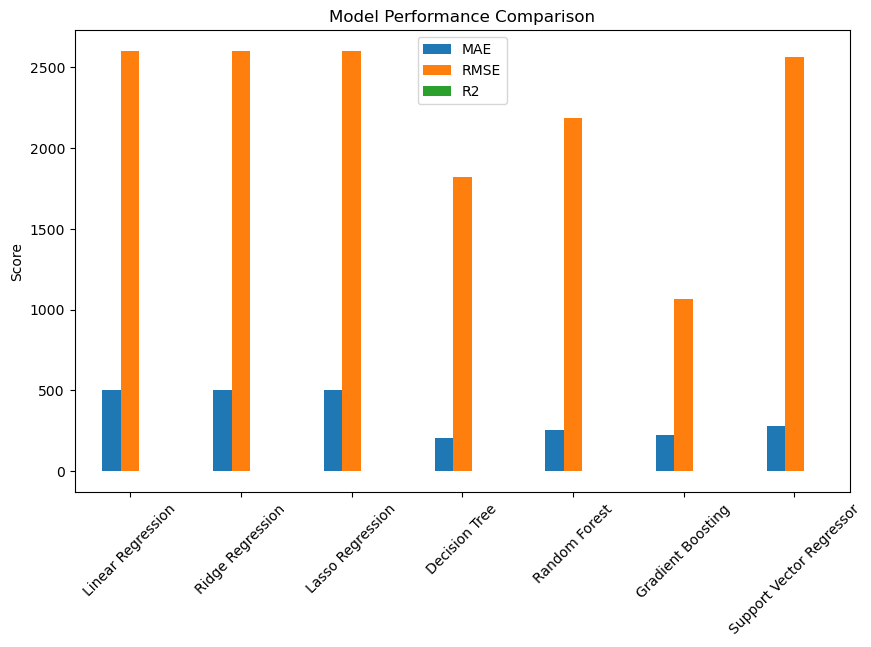

In [14]:
file_path =  r"C:\Users\dhruv\OneDrive\Desktop\ml\listings.csv"
target_column = "price"      

    # Load dataset
X_train, X_test, y_train, y_test = load_data(file_path, target_column)

    # Train models
models = get_models()
for name, model in models.items():
    model.fit(X_train, y_train)

    # Compare & evaluate
results_df, preds = compare_models(models, X_test, y_test)
print("Model Performance:\n", results_df)

    # Plot results
plot_results(y_test, preds, results_df)